In [179]:
import os
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.2"  # Limit JAX to use at most 20% of GPU memory
import jax

import jax.numpy as jnp
from temgym_core.components import Detector
from temgym_core.transfer_matrices import calculate_z1_and_z2_from_M_and_f
from temgym_core.constants import (
    compute_Kv_from_voltage,
    compute_I0_Cf_from_focal_rotation
)
from temgym_core.components import ElectromagneticLens
from temgym_core.run import run_to_end_vmapped
from temgym_core.source import square_input_wave
from temgym_core.components import RotatingLens
from temgym_core.run import run_to_end as run_to_end_for_abcd
from temgym_core.evaluate import evaluate_gaussians_jax_scan
import numpy as np
import matplotlib.pyplot as plt

jax.config.update("jax_enable_x64", True)

%matplotlib widget




In [180]:
voltage = 200e3 # V
M1 = -100
M2 = -100
f1 = 1e-3
psi1 = np.pi # rad
f2 = 10e-3
psi2 = np.pi # rad

Rc = compute_Kv_from_voltage(voltage) # V
I1, Cf1 = compute_I0_Cf_from_focal_rotation(f1, psi1, Kv)
I2, Cf2 = compute_I0_Cf_from_focal_rotation(f2, psi2, Kv)

z1_L1, z2_L1 = calculate_z1_and_z2_from_M_and_f(M1, f1)
z1_L2, z2_L2 = calculate_z1_and_z2_from_M_and_f(M2, f2)
lens_z1 = np.abs(z1_L1)
lens_z2 = lens_z1 + np.abs(z2_L1) + np.abs(z1_L2)
detector_z = lens_z2 + np.abs(z2_L2)
lens1 = ElectromagneticLens(I0=I1, Cf=Cf1, z=lens_z1, Kv=Kv)
lens2 = ElectromagneticLens(I0=I2, Cf=Cf2, z=lens_z2, Kv=Kv)

input_aperture_width = 1e-6
input_image_shape = (256, 256)
input_window_width = input_aperture_width * 2
input_pixel_size = input_window_width / 256
input_detector = Detector(z=0, pixel_size=(input_pixel_size, input_pixel_size), shape=input_image_shape)

output_detector_width = 10e-3
output_image_shape = (256, 256)
output_pixel_size = output_detector_width / 256
output_detector = Detector(z=detector_z, pixel_size=(output_pixel_size, output_pixel_size), shape=output_image_shape)

input_rays = square_input_wave(input_aperture_width, waist=1e-8, voltage=voltage, overlap_factor=2.0)
input_aperture_image = evaluate_gaussians_jax_scan(input_rays, input_detector)

Text(0.5, 1.0, 'Input Aperture Image')

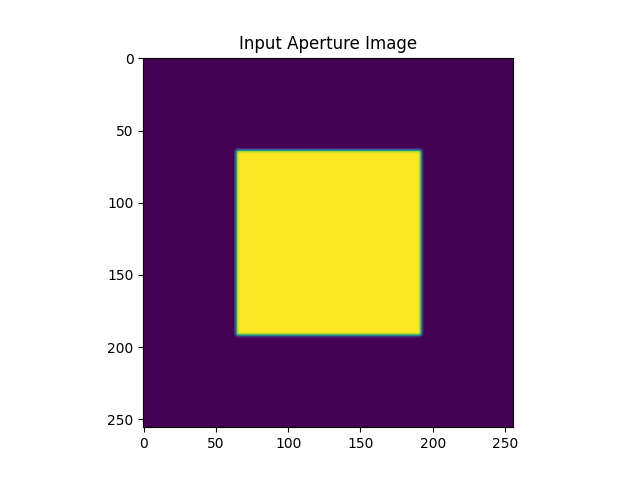

In [181]:

plt.figure()
plt.imshow(np.abs(input_aperture_image))
plt.title("Input Aperture Image")

In [182]:
import sympy as sp

from temgym_core.transfer_matrices import propagation_matrix, lens_matrix, rotation_matrix
from temgym_core.utils import FresnelPropagator
import jax.scipy.ndimage as jndimage

def build_abcd(dists, focals, rotations, xp=jnp):
    """Construct ABCD matrix for N-lens system.

    dists: length N+1, focals: length N
    M = P(d_{N+1}) L_N ... L_1 P(d_1)
    """
    M = propagation_matrix(dists[-1], xp=xp)
    for i in reversed(range(len(focals))):
        M = M @ lens_matrix(focals[i], xp=xp)
        M = M @ rotation_matrix(rotations[i], xp=xp)
        M = M @ propagation_matrix(dists[i], xp=xp)
    return M


def compute_AB(dists, focals, rotations):
    M = build_abcd(dists, focals, rotations, xp=jnp)
    return M[0, 0], M[0, 1]


def detector_window_width(detector):
    return detector.pixel_size[0] * detector.shape[0]


def resample_intensity_with_detectors(
    source_intensity,
    source_detector,
    target_detector,
    scale,
    rotation_rad,
    *,
    order=1,
    cval=0.0,
    eps=1e-12,
 ):
    if jnp.abs(scale) < eps:
        scale = jnp.sign(scale) * eps
    yy_px, xx_px = target_detector.coords_px
    x_m, y_m = target_detector.pixels_to_metres((yy_px, xx_px))
    c = jnp.cos(rotation_rad)
    s = jnp.sin(rotation_rad)
    x_in = (c * x_m - s * y_m) / scale
    y_in = (s * x_m + c * y_m) / scale
    y_src_px, x_src_px = source_detector.metres_to_pixels((x_in, y_in), cast=False)
    coords = jnp.stack([y_src_px, x_src_px], axis=0)
    return jndimage.map_coordinates(
        source_intensity, coords, order=order, mode="constant", cval=cval
    )


def defocus_intensity(intensity, det_window_width, wavelength, defocus):
    amplitude = jnp.sqrt(jnp.maximum(intensity, 1e-12)).astype(jnp.complex128)
    field_defocused = FresnelPropagator(amplitude, det_window_width, wavelength, defocus)
    return jnp.maximum(jnp.abs(field_defocused) ** 2, 1e-12)


def create_wobbled_lenses(lenses, wobble_vector):
    """Create wobbled versions of lenses by applying relative current perturbation.

    Args:
        lenses: list of ElectromagneticLens objects
        wobble_vector: array of shape (n_lenses,), relative perturbations w_i
                      where I0_wobbled = I0 * (1 + w_i)
    Returns:
        list of new ElectromagneticLens objects with wobbled I0 values
    """
    wobbled = []
    for i, lens in enumerate(lenses):
        I0_wobbled = lens.I0 * (1.0 + wobble_vector[i])
        # Create new lens with wobbled I0, keeping Cf, Rc the same
        wobbled_lens = ElectromagneticLens(
            I0=I0_wobbled,
            Cf=lens.Cf,
            z=lens.z,
            Kv=lens.Kv
        )
        wobbled.append(wobbled_lens)
    return wobbled


def generate_wobble_grid(wobble_scale, n_wobbles_per_lens):
    """Generate uniformly-spaced wobble values around +/- wobble_scale.

    For n_wobbles_per_lens=6 and wobble_scale=0.05:
        Returns [-0.05, -0.03, -0.01, 0.01, 0.03, 0.05]
    Args:
        wobble_scale: half-width of wobble range (e.g., 0.05 for +/- 5%)
        n_wobbles_per_lens: number of wobble points to generate
    Returns:
        array of shape (n_wobbles_per_lens,), uniformly spaced wobbles
    """
    # Generate symmetric wobbles around 0, excluding 0
    if n_wobbles_per_lens % 2 == 0:
        # Even: symmetric around 0
        half_n = n_wobbles_per_lens // 2
        neg_wobbles = -np.linspace(wobble_scale / half_n, wobble_scale, half_n)
        pos_wobbles = np.linspace(wobble_scale / half_n, wobble_scale, half_n)
        wobbles_1d = np.concatenate([neg_wobbles, pos_wobbles])
    else:
        # Odd: include 0 in the middle
        half_n = n_wobbles_per_lens // 2
        neg_wobbles = -np.linspace(wobble_scale / (half_n + 1), wobble_scale, half_n)
        pos_wobbles = np.linspace(wobble_scale / (half_n + 1), wobble_scale, half_n)
        wobbles_1d = np.concatenate([neg_wobbles, [0.0], pos_wobbles])

    return wobbles_1d


def generate_wobble_individual_ensemble(
    source_intensity,
    source_detector,
    target_detector,
    wavelength,
    nominal_lenses,
    wobble_scale,
    n_wobbles_per_lens,
 ):
    """Generate ensemble by varying each lens individually (one at a time).
    Args:
        source_intensity: base intensity image at source_detector
        source_detector: Detector defining the source coordinate system
        target_detector: Detector defining the target coordinate system
        wavelength: wavelength in metres
        nominal_lenses: list of nominal ElectromagneticLens objects
        wobble_scale: half-width of wobble range for each lens (e.g., 0.05 for +/- 5%)
        n_wobbles_per_lens: number of wobble points per lens (e.g., 6)
    Returns:
        tuple: (images_array, lens_indices, wobble_indices, wobble_values, abcd_matrices)
               - images_array: shape (n_total, height, width), intensity images
               - lens_indices: shape (n_total,), which lens was perturbed
               - wobble_indices: shape (n_total,), index into wobble grid for this lens
               - wobble_values: shape (n_total,), actual wobble value applied
               - abcd_matrices: shape (n_total, 3, 3), ABCD matrix for each configuration
    """
    n_lenses = len(nominal_lenses)

    # Generate 1D wobble grid
    wobble_grid_1d = generate_wobble_grid(wobble_scale, n_wobbles_per_lens)

    images = []
    lens_indices_list = []
    wobble_indices_list = []
    wobble_values_list = []
    abcd_matrices_list = []

    # For each lens
    for lens_idx in range(n_lenses):
        # For each wobble value
        for wobble_idx, wobble_val in enumerate(wobble_grid_1d):
            # Create wobble vector (all zeros except for this lens)
            wobble_vector = np.zeros(n_lenses)
            wobble_vector[lens_idx] = wobble_val

            # Create wobbled lenses
            wobbled_lenses = create_wobbled_lenses(nominal_lenses, wobble_vector)

            zs = []
            fs = []
            # Calculate ABCD of wobbled lenses WITHOUT rotation in the matrix
            # (rotation will be applied separately to the resampling)
            for lens in wobbled_lenses:
                zs.append(lens.z)
                fs.append(lens.focal_length)

            zs.append(target_detector.z)
            zs = [zs[0]] + list(np.diff(zs))  # Convert to distances between elements

            # Store rotations separately, don't include in ABCD
            phi = [lens.rotation_angle for lens in wobbled_lenses]
            ABCD = build_abcd(zs, fs, [0.0]*len(fs), xp=jnp)  # No rotation in matrix
            abcd_matrices_list.append(np.array(ABCD))

            a_val = float(ABCD[0, 0])
            b_val = float(ABCD[0, 1])
            if np.abs(a_val) < 1e-12:
                a_val = np.sign(a_val) * 1e-12
            
            # The ABCD A value is now the true magnification (rotation removed)
            scale = a_val
            effective_defocus = b_val * a_val
            rotation = float(np.sum(phi))
            if scale < 0.0:
                scale = -scale
                rotation += np.pi

            resampled = resample_intensity_with_detectors(
                source_intensity,
                source_detector,
                target_detector,
                scale,
                rotation,
                order=1,
                cval=0.0,
            )
            det_window_width = detector_window_width(target_detector)
            defocused = defocus_intensity(
                resampled, det_window_width, wavelength, effective_defocus
            )
            images.append(np.array(defocused))
            lens_indices_list.append(lens_idx)
            wobble_indices_list.append(wobble_idx)
            wobble_values_list.append(wobble_val)

    images_array = np.stack(images) if images else np.empty((0, *target_detector.shape))
    lens_indices_array = np.array(lens_indices_list)
    wobble_indices_array = np.array(wobble_indices_list)
    wobble_values_array = np.array(wobble_values_list)
    abcd_matrices_array = np.array(abcd_matrices_list)

    return (
        images_array,
        lens_indices_array,
        wobble_indices_array,
        wobble_values_array,
        abcd_matrices_array,
    )

In [183]:
# Generate individual wobble ensemble (one lens at a time)
from temgym_core.constants import energy2wavelength

wobble_scale = 0.2
n_wobbles_per_lens = 3

print(f"Generating individual wobble ensemble with wobble_scale=±{wobble_scale*100:.1f}% and {n_wobbles_per_lens} wobbles per lens")

source_intensity = jnp.abs(input_aperture_image) ** 2
wavelength = energy2wavelength(voltage)

ensemble_images, lens_indices, wobble_indices, wobble_values, abcd_matrices = generate_wobble_individual_ensemble(
    source_intensity,
    source_detector=input_detector,
    target_detector=output_detector,
    wavelength=wavelength,
    nominal_lenses=[lens1, lens2],
    wobble_scale=wobble_scale,
    n_wobbles_per_lens=n_wobbles_per_lens
 )

print(f"\nEnsemble shape: {ensemble_images.shape}")
print(f"Total images: {len(ensemble_images)}")

# Show wobble grid
wobble_grid_1d = generate_wobble_grid(wobble_scale, n_wobbles_per_lens)
print(f"\nWobble grid (×100%):")
print(f"  {wobble_grid_1d * 100}")
print(f"  range=[{wobble_grid_1d.min()*100:.2f}%, {wobble_grid_1d.max()*100:.2f}%]")

# Show breakdown by lens
for lens_idx in range(len([lens1, lens2])):
    mask = lens_indices == lens_idx
    print(f"\nLens {lens_idx+1}: {np.sum(mask)} images")
    print(f"  Wobbles: {wobble_values[mask]}")

print("\nABCD matrices per configuration:")
for idx, abcd in enumerate(abcd_matrices):
    lens_idx = int(lens_indices[idx])
    wobble_idx = int(wobble_indices[idx])
    wobble_val = float(wobble_values[idx])
    a_val = float(abcd[0, 0])
    b_val = float(abcd[0, 1])
    effective_defocus = (b_val / a_val) * a_val**2
    print(
        f"[{idx:03d}] lens={lens_idx+1}, wobble_idx={wobble_idx}, wobble={wobble_val:+.4f} -> "
        f"A={a_val:.6e}, B={b_val:.6e}, effective_defocus={effective_defocus:.6e}"
    )

Generating individual wobble ensemble with wobble_scale=±20.0% and 3 wobbles per lens

Ensemble shape: (6, 256, 256)
Total images: 6

Wobble grid (×100%):
  [-10.   0.  10.]
  range=[-10.00%, 10.00%]

Lens 1: 3 images
  Wobbles: [-0.1  0.   0.1]

Lens 2: 3 images
  Wobbles: [-0.1  0.   0.1]

ABCD matrices per configuration:
[000] lens=1, wobble_idx=0, wobble=-0.1000 -> A=8.081000e+03, B=-1.938190e+00, effective_defocus=-1.566251e+04
[001] lens=1, wobble_idx=1, wobble=+0.0000 -> A=1.000000e+04, B=0.000000e+00, effective_defocus=0.000000e+00
[002] lens=1, wobble_idx=2, wobble=+0.1000 -> A=1.212100e+04, B=2.142210e+00, effective_defocus=2.596573e+04
[003] lens=2, wobble_idx=0, wobble=-0.1000 -> A=7.887181e+03, B=-1.938190e-03, effective_defocus=-1.528686e+01
[004] lens=2, wobble_idx=1, wobble=+0.0000 -> A=1.000000e+04, B=0.000000e+00, effective_defocus=0.000000e+00
[005] lens=2, wobble_idx=2, wobble=+0.1000 -> A=1.233522e+04, B=2.142210e-03, effective_defocus=2.642463e+01


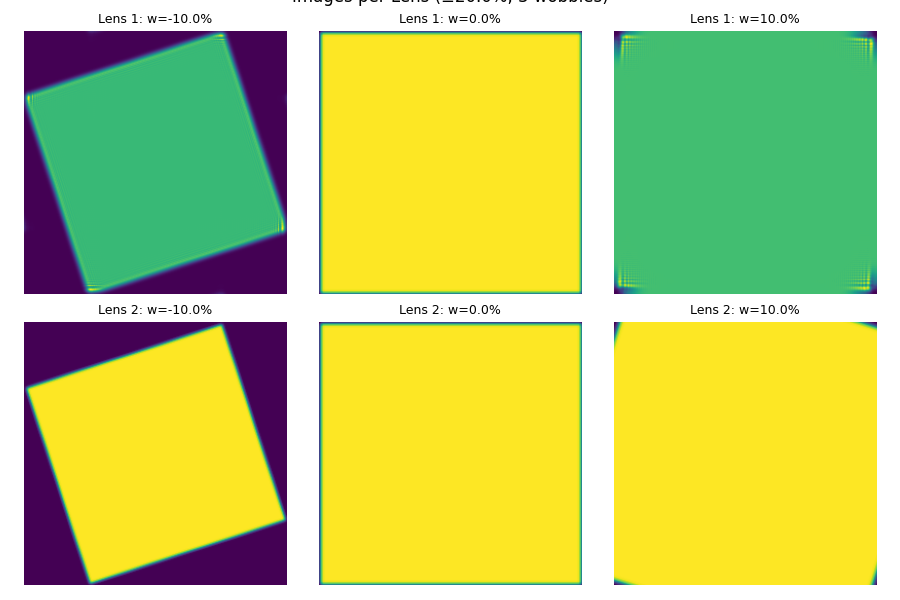

In [184]:
# Visualize all images per lens (no ensemble stats)
n_lenses = len(np.unique(lens_indices))
n_cols = n_wobbles_per_lens
fig, axes = plt.subplots(n_lenses, n_cols, figsize=(3 * n_cols, 3 * n_lenses))
if n_cols == 1:
    axes = axes[:, np.newaxis]  # Ensure axes is 2D for consistent indexing
    
for lens_idx in range(n_lenses):
    lens_mask = lens_indices == lens_idx
    lens_images = ensemble_images[lens_mask]
    lens_wobbles = wobble_values[lens_mask]
    for j in range(n_cols):
        ax = axes[lens_idx, j] if n_lenses > 1 else axes[j]
        ax.imshow(np.abs(lens_images[j]))
        ax.set_title(f"Lens {lens_idx+1}: w={lens_wobbles[j]*100:.1f}%", fontsize=9)
        ax.axis("off")

plt.tight_layout()
plt.suptitle(
    f"Images per Lens (±{wobble_scale*100:.1f}%, {n_wobbles_per_lens} wobbles)",
    fontsize=12,
    y=1.02
)
plt.show()


## 4-Lens Microscope System (Condenser, Objective, Intermediate, Projector)

In [185]:
# Define a realistic microscope system without condenser
# Configuration:
#   1. Objective lens: first stage magnification
#   2. Intermediate lens 1: second stage magnification
#   3. Intermediate lens 2: third stage magnification
#   4. Projector lens: final stage magnification

voltage_4 = 200e3  # 200 keV (consistent with 2-lens system)

# Objective lens
M_obj = -50.0
f_obj = 5e-3     # 5 mm focal length
psi_obj = np.pi  # 180 deg

# Intermediate lens 1
M_inter1 = -4.0
f_inter1 = 7e-3   # 7 mm focal length
psi_inter1 = np.pi/3  # 60 deg

# Intermediate lens 2
M_inter2 = -3.0
f_inter2 = 8e-3   # 8 mm focal length
psi_inter2 = np.pi/4  # 45 deg

# Projector lens
M_proj = -2.0
f_proj = 15e-3   # 15 mm focal length
psi_proj = np.pi # 180 deg

# Total magnification
total_mag = M_obj * M_inter1 * M_inter2 * M_proj
print(f"Microscope System Configuration (200 keV):")
print(f"  Objective: M={M_obj}, f={f_obj*1e3:.1f} mm, rotation={psi_obj*180/np.pi:.1f}°")
print(f"  Intermediate 1: M={M_inter1}, f={f_inter1*1e3:.1f} mm, rotation={psi_inter1*180/np.pi:.1f}°")
print(f"  Intermediate 2: M={M_inter2}, f={f_inter2*1e3:.1f} mm, rotation={psi_inter2*180/np.pi:.1f}°")
print(f"  Projector: M={M_proj}, f={f_proj*1e3:.1f} mm, rotation={psi_proj*180/np.pi:.1f}°")
print(f"  Total magnification: {total_mag:.0f}x")

# Set up system
Kv_4 = compute_Kv_from_voltage(voltage_4)

I_obj, Cf_obj = compute_I0_Cf_from_focal_rotation(f_obj, psi_obj, Kv_4)
I_inter1, Cf_inter1 = compute_I0_Cf_from_focal_rotation(f_inter1, psi_inter1, Kv_4)
I_inter2, Cf_inter2 = compute_I0_Cf_from_focal_rotation(f_inter2, psi_inter2, Kv_4)
I_proj, Cf_proj = compute_I0_Cf_from_focal_rotation(f_proj, psi_proj, Kv_4)

print(f"\nLens currents:")
print(f"  Objective: I0={I_obj:.6e} A, Cf={Cf_obj:.6e}")
print(f"  Intermediate 1: I0={I_inter1:.6e} A, Cf={Cf_inter1:.6e}")
print(f"  Intermediate 2: I0={I_inter2:.6e} A, Cf={Cf_inter2:.6e}")
print(f"  Projector: I0={I_proj:.6e} A, Cf={Cf_proj:.6e}")

# Calculate positions using imaging equations
z1_obj, z2_obj = calculate_z1_and_z2_from_M_and_f(M_obj, f_obj)
z1_inter1, z2_inter1 = calculate_z1_and_z2_from_M_and_f(M_inter1, f_inter1)
z1_inter2, z2_inter2 = calculate_z1_and_z2_from_M_and_f(M_inter2, f_inter2)
z1_proj, z2_proj = calculate_z1_and_z2_from_M_and_f(M_proj, f_proj)

# Position lenses sequentially
lens_z_obj = np.abs(z1_obj)
lens_z_inter1 = lens_z_obj + np.abs(z2_obj) + np.abs(z1_inter1)
lens_z_inter2 = lens_z_inter1 + np.abs(z2_inter1) + np.abs(z1_inter2)
lens_z_proj = lens_z_inter2 + np.abs(z2_inter2) + np.abs(z1_proj)
detector_z_4 = lens_z_proj + np.abs(z2_proj)

print(f"\nLens positions:")
print(f"  Objective: z={lens_z_obj:.6e} m")
print(f"  Intermediate 1: z={lens_z_inter1:.6e} m")
print(f"  Intermediate 2: z={lens_z_inter2:.6e} m")
print(f"  Projector: z={lens_z_proj:.6e} m")
print(f"  Detector: z={detector_z_4:.6e} m")

# Create lens objects
lens_obj = ElectromagneticLens(I0=I_obj, Cf=Cf_obj, z=lens_z_obj, Kv=Kv_4)
lens_inter1 = ElectromagneticLens(I0=I_inter1, Cf=Cf_inter1, z=lens_z_inter1, Kv=Kv_4)
lens_inter2 = ElectromagneticLens(I0=I_inter2, Cf=Cf_inter2, z=lens_z_inter2, Kv=Kv_4)
lens_proj = ElectromagneticLens(I0=I_proj, Cf=Cf_proj, z=lens_z_proj, Kv=Kv_4)

# Set up detectors
# Input aperture (specimen plane)
input_aperture_width_4 = 1e-6  # 1 micron
input_image_shape_4 = (256, 256)
input_window_width_4 = input_aperture_width_4 * 2
input_pixel_size_4 = input_window_width_4 / 256
input_detector_4 = Detector(z=0, pixel_size=(input_pixel_size_4, input_pixel_size_4), shape=input_image_shape_4)

# Output detector (diffraction plane / screen)
output_detector_width_4 = 10e-3
output_image_shape_4 = (256, 256)
output_pixel_size_4 = output_detector_width_4 / 256
output_detector_4 = Detector(z=detector_z_4, pixel_size=(output_pixel_size_4, output_pixel_size_4), shape=output_image_shape_4)

# Create input beam
input_rays_4 = square_input_wave(input_aperture_width_4, waist=5e-9, voltage=voltage_4, overlap_factor=2.0)
input_aperture_image_4 = evaluate_gaussians_jax_scan(input_rays_4, input_detector_4)

print(f"\nDetector setup:")
print(f"  Input aperture: {input_aperture_width_4*1e6:.2f} μm, pixel size {input_pixel_size_4*1e9:.2f} nm")
print(f"  Output screen: {output_detector_width_4*1e3:.1f} mm, pixel size {output_pixel_size_4*1e6:.2f} μm")


Microscope System Configuration (200 keV):
  Objective: M=-50.0, f=5.0 mm, rotation=180.0°
  Intermediate 1: M=-4.0, f=7.0 mm, rotation=60.0°
  Intermediate 2: M=-3.0, f=8.0 mm, rotation=45.0°
  Projector: M=-2.0, f=15.0 mm, rotation=180.0°
  Total magnification: 1200x

Lens currents:
  Objective: I0=5.925849e+03 A, Cf=5.695461e-06
  Intermediate 1: I0=1.975283e+03 A, Cf=3.661367e-05
  Intermediate 2: I0=1.481462e+03 A, Cf=5.695461e-05
  Projector: I0=5.925849e+03 A, Cf=1.898487e-06

Lens positions:
  Objective: z=5.100000e-03 m
  Intermediate 1: z=2.688500e-01 m
  Intermediate 2: z=3.145167e-01 m
  Projector: z=3.690167e-01 m
  Detector: z=4.140167e-01 m

Detector setup:
  Input aperture: 1.00 μm, pixel size 7.81 nm
  Output screen: 10.0 mm, pixel size 39.06 μm


In [186]:
# Debug: Verify lens positioning for cascaded imaging mode
print("\n" + "="*70)
print("CASCADED IMAGING MODE VERIFICATION")
print("="*70)

# For each stage, verify that:
# 1. Object plane is at correct distance before the lens
# 2. Image plane is at correct distance after the lens
# 3. Magnification relationship is satisfied

stages = [
    ("Objective", lens_z_obj, f_obj, M_obj, z1_obj, z2_obj),
    ("Inter1", lens_z_inter1, f_inter1, M_inter1, z1_inter1, z2_inter1),
    ("Inter2", lens_z_inter2, f_inter2, M_inter2, z1_inter2, z2_inter2),
    ("Projector", lens_z_proj, f_proj, M_proj, z1_proj, z2_proj),
]

object_planes = [0.0]  # Start with object at z=0
for i, (name, lens_z, f, M, z1, z2) in enumerate(stages):
    obj_z = object_planes[-1]
    expected_lens_z = obj_z + abs(z1)  # Lens should be at obj + distance_to_lens
    image_z = lens_z + abs(z2)  # Image should be at lens + distance_from_lens
    
    print(f"\n{name}:")
    print(f"  Object plane z:     {obj_z:.6e} m")
    print(f"  Lens z (actual):    {lens_z:.6e} m")
    print(f"  Lens z (expected):  {expected_lens_z:.6e} m")
    print(f"  Match? {np.isclose(lens_z, expected_lens_z, rtol=1e-6)}")
    print(f"  Image plane z:      {image_z:.6e} m")
    print(f"  M from formula:     {M:.2f}")
    
    # Verify imaging relationship: 1/z1 + 1/z2 = 1/f
    if abs(z1) > 1e-12 and abs(z2) > 1e-12:
        lhs = 1.0/abs(z1) + 1.0/abs(z2)
        rhs = 1.0/f
        print(f"  Lens equation: 1/|z1| + 1/|z2| = {lhs:.6e}, 1/f = {rhs:.6e}")
        print(f"  Satisfied? {np.isclose(lhs, rhs, rtol=1e-4)}")
    
    object_planes.append(image_z)

# Now check: what is the actual magnification product?
print(f"\n" + "="*70)
print("MAGNIFICATION CHECK:")
print(f"  M_obj × M_inter1 × M_inter2 × M_proj = {M_obj} × {M_inter1} × {M_inter2} × {M_proj}")
print(f"  = {M_obj * M_inter1} × {M_inter2 * M_proj} = {M_obj * M_inter1 * M_inter2 * M_proj}")
print(f"  Absolute value: {abs(M_obj * M_inter1 * M_inter2 * M_proj)}")

# Build a single ABCD for each stage to verify A values
print(f"\n" + "="*70)
print("INDIVIDUAL STAGE ABCD A-VALUES:")
individual_mags = []
for i, (name, lens_z, f, M, z1, z2) in enumerate(stages):
    z_list_single = [abs(z1), abs(z2)]
    f_list_single = [f]
    phi_list_single = [stages[i][4] if i < len(stages) else 0]  # Get rotation angle
    
    # Get actual rotation angle from the original definition
    rotations_all = [psi_obj, psi_inter1, psi_inter2, psi_proj]
    
    ABCD_single = build_abcd(z_list_single, [f], [rotations_all[i]], xp=jnp)
    A_single = float(ABCD_single[0, 0])
    individual_mags.append(abs(A_single))
    print(f"  {name:12s}: A = {A_single:10.2f}, Expected M = {abs(M):10.2f}, Ratio = {abs(A_single)/abs(M):.4f}")

# Product of A values from individual stages
prod_A_individual = np.prod(individual_mags)
print(f"\nProduct of individual A values: {prod_A_individual:.2f}")
print(f"Expected total magnification: {abs(M_obj * M_inter1 * M_inter2 * M_proj):.0f}")


CASCADED IMAGING MODE VERIFICATION

Objective:
  Object plane z:     0.000000e+00 m
  Lens z (actual):    5.100000e-03 m
  Lens z (expected):  5.100000e-03 m
  Match? True
  Image plane z:      2.601000e-01 m
  M from formula:     -50.00
  Lens equation: 1/|z1| + 1/|z2| = 2.000000e+02, 1/f = 2.000000e+02
  Satisfied? True

Inter1:
  Object plane z:     2.601000e-01 m
  Lens z (actual):    2.688500e-01 m
  Lens z (expected):  2.688500e-01 m
  Match? True
  Image plane z:      3.038500e-01 m
  M from formula:     -4.00
  Lens equation: 1/|z1| + 1/|z2| = 1.428571e+02, 1/f = 1.428571e+02
  Satisfied? True

Inter2:
  Object plane z:     3.038500e-01 m
  Lens z (actual):    3.145167e-01 m
  Lens z (expected):  3.145167e-01 m
  Match? True
  Image plane z:      3.465167e-01 m
  M from formula:     -3.00
  Lens equation: 1/|z1| + 1/|z2| = 1.250000e+02, 1/f = 1.250000e+02
  Satisfied? True

Projector:
  Object plane z:     3.465167e-01 m
  Lens z (actual):    3.690167e-01 m
  Lens z (expected)

In [187]:
# Check if rotation matrices are causing the problem
print(f"\n" + "="*70)
print("ROTATION MATRIX IMPACT CHECK:")
print("="*70)

for i, (name, lens_z, f, M, z1, z2) in enumerate(stages):
    z_list_single = [abs(z1), abs(z2)]
    f_list_single = [f]
    rotations_all = [psi_obj, psi_inter1, psi_inter2, psi_proj]
    
    # Test WITHOUT rotation
    ABCD_no_rot = build_abcd(z_list_single, [f], [0.0], xp=jnp)
    A_no_rot = float(ABCD_no_rot[0, 0])
    
    # Test WITH rotation
    ABCD_with_rot = build_abcd(z_list_single, [f], [rotations_all[i]], xp=jnp)
    A_with_rot = float(ABCD_with_rot[0, 0])
    
    print(f"{name:12s}: A(no_rot)={A_no_rot:10.2f}, A(with_rot)={A_with_rot:10.2f}")

# Check rotation matrix itself
from temgym_core.transfer_matrices import rotation_matrix
print(f"\nRotation matrix for π:")
R_pi = rotation_matrix(np.pi, xp=jnp)
print(np.array(R_pi[0:2, 0:2]))
print(f"\nRotation matrix for π/3:")
R_pi3 = rotation_matrix(np.pi/3, xp=jnp)
print(np.array(R_pi3[0:2, 0:2]))


ROTATION MATRIX IMPACT CHECK:
Objective   : A(no_rot)=    -50.00, A(with_rot)=     50.00
Inter1      : A(no_rot)=     -4.00, A(with_rot)=     -2.03
Inter2      : A(no_rot)=     -3.00, A(with_rot)=     -2.14
Projector   : A(no_rot)=     -2.00, A(with_rot)=      2.00

Rotation matrix for π:
[[-1.0000000e+00  1.2246468e-16]
 [-1.2246468e-16 -1.0000000e+00]]

Rotation matrix for π/3:
[[ 0.5        0.8660254]
 [-0.8660254  0.5      ]]


In [188]:
# Generate ensemble with microscope system
wobble_scale_4 = 0.3
n_wobbles_per_lens_4 = 3  # 3 wobbles per lens

print(f"\nGenerating ensemble with wobble_scale=±{wobble_scale_4*100:.1f}% and {n_wobbles_per_lens_4} wobbles per lens")
print(f"Total images: {4 * n_wobbles_per_lens_4} (4 lenses x {n_wobbles_per_lens_4} wobbles)")

source_intensity_4 = jnp.abs(input_aperture_image_4) ** 2
wavelength_4 = energy2wavelength(voltage_4)

ensemble_images_4, lens_indices_4, wobble_indices_4, wobble_values_4, abcd_matrices_4 = generate_wobble_individual_ensemble(
    source_intensity_4,
    source_detector=input_detector_4,
    target_detector=output_detector_4,
    wavelength=wavelength_4,
    nominal_lenses=[lens_obj, lens_inter1, lens_inter2, lens_proj],
    wobble_scale=wobble_scale_4,
    n_wobbles_per_lens=n_wobbles_per_lens_4
 )

print(f"\nEnsemble shape: {ensemble_images_4.shape}")
print(f"Total images: {len(ensemble_images_4)}")

# Show wobble grid
wobble_grid_1d_4 = generate_wobble_grid(wobble_scale_4, n_wobbles_per_lens_4)
print(f"\nWobble grid (×100%): {wobble_grid_1d_4 * 100}")

# Show breakdown by lens
lens_names_4 = ['Objective', 'Intermediate 1', 'Intermediate 2', 'Projector']
for lens_idx in range(4):
    mask = lens_indices_4 == lens_idx
    n_imgs = np.sum(mask)
    if n_imgs > 0:
        print(f"\n{lens_names_4[lens_idx]} (lens {lens_idx+1}): {n_imgs} images")
        print(f"  Wobbles: {wobble_values_4[mask]}")

# Show representative ABCD matrices
print(f"\nABCD matrices per configuration (sample):")
for idx in range(min(4, len(abcd_matrices_4))):  
    lens_idx = int(lens_indices_4[idx])
    wobble_val = float(wobble_values_4[idx])
    a_val = float(abcd_matrices_4[idx][0, 0])
    b_val = float(abcd_matrices_4[idx][0, 1])
    effective_defocus = b_val / a_val
    print(
        f"[{idx:02d}] {lens_names_4[lens_idx]:15s}: wobble={wobble_val:+.2f}, "
        f"A={a_val:8.1f}, B={b_val:8.1f} m, defocus(B/A)={effective_defocus:8.4f} m"
    )



Generating ensemble with wobble_scale=±30.0% and 3 wobbles per lens
Total images: 12 (4 lenses x 3 wobbles)

Ensemble shape: (12, 256, 256)
Total images: 12

Wobble grid (×100%): [-15.   0.  15.]

Objective (lens 1): 3 images
  Wobbles: [-0.15  0.    0.15]

Intermediate 1 (lens 2): 3 images
  Wobbles: [-0.15  0.    0.15]

Intermediate 2 (lens 3): 3 images
  Wobbles: [-0.15  0.    0.15]

Projector (lens 4): 3 images
  Wobbles: [-0.15  0.    0.15]

ABCD matrices per configuration (sample):
[00] Objective      : wobble=-0.15, A=   860.3, B=    -1.7 m, defocus(B/A)= -0.0020 m
[01] Objective      : wobble=+0.00, A=  1200.0, B=     0.0 m, defocus(B/A)=  0.0000 m
[02] Objective      : wobble=+0.15, A=  1594.7, B=     2.0 m, defocus(B/A)=  0.0013 m
[03] Intermediate 1 : wobble=-0.15, A=   769.2, B=    -0.0 m, defocus(B/A)= -0.0000 m


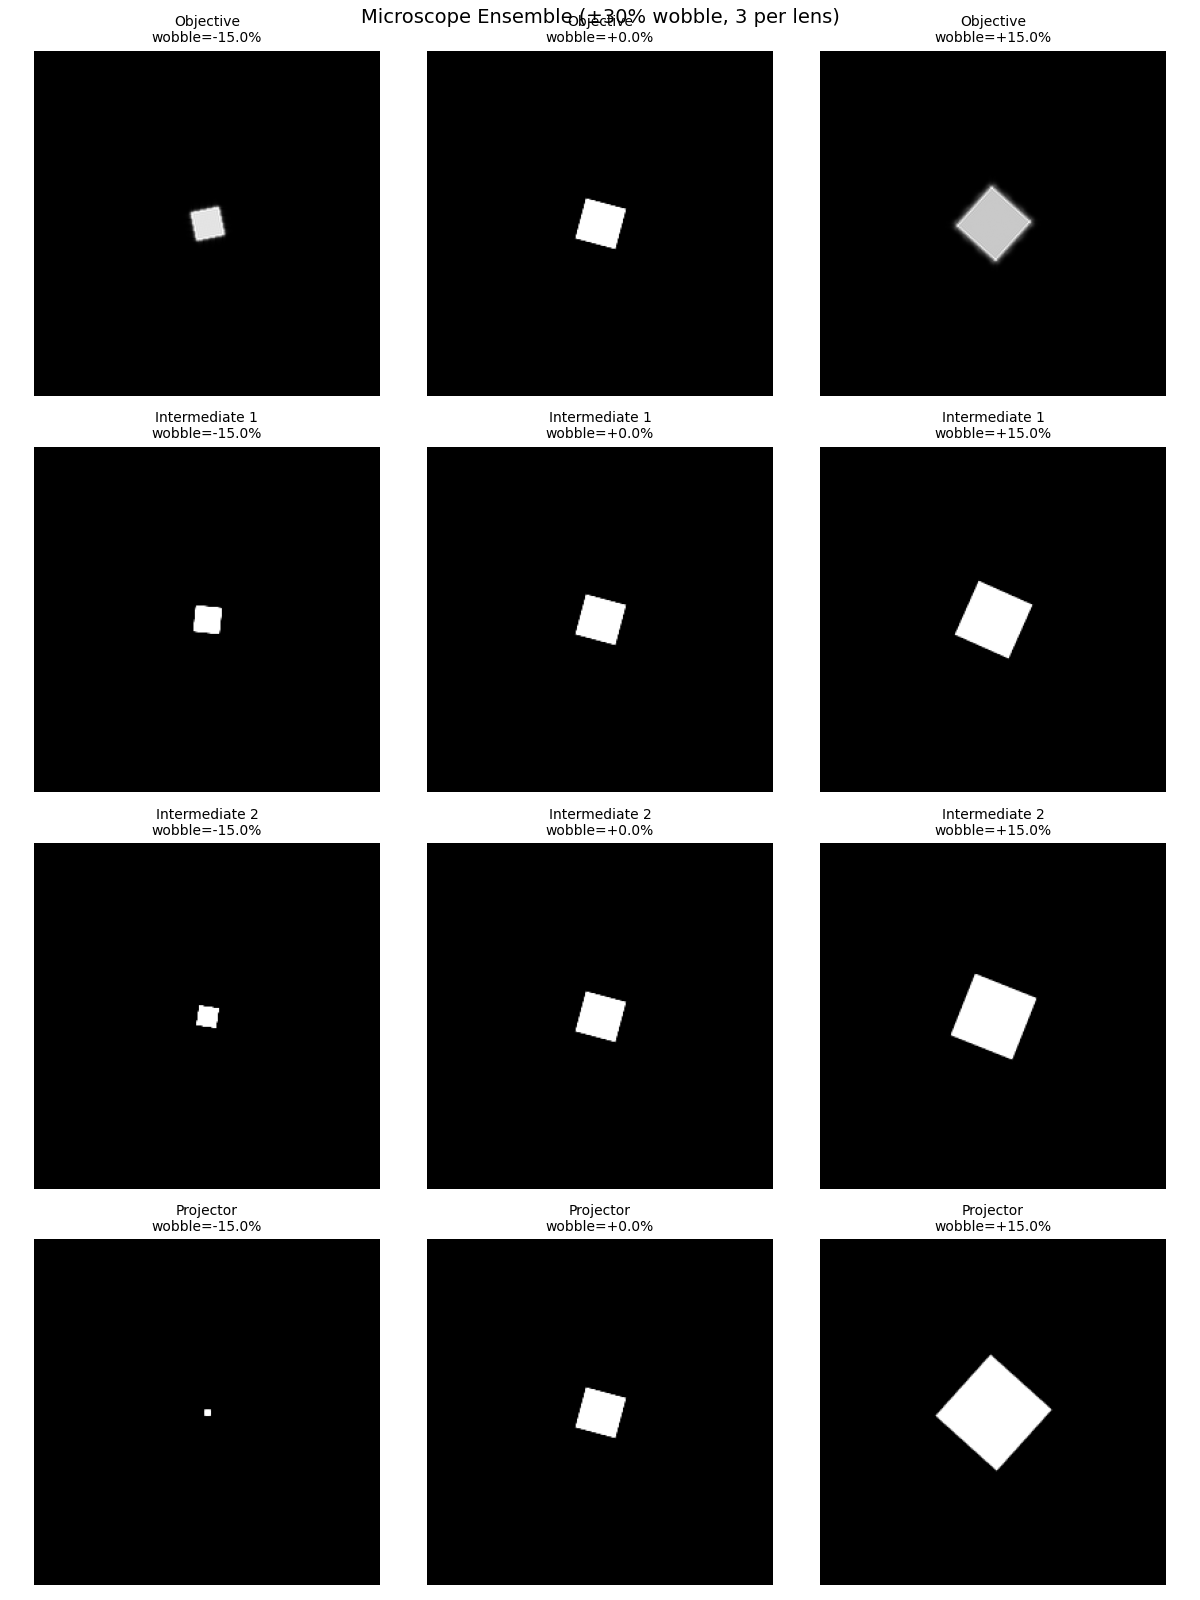

In [189]:
# Visualize ensemble images
n_lenses_4 = 4
n_cols_4 = n_wobbles_per_lens_4

fig, axes = plt.subplots(n_lenses_4, n_cols_4, figsize=(4 * n_cols_4, 4 * n_lenses_4))

for lens_idx in range(n_lenses_4):
    lens_mask = lens_indices_4 == lens_idx
    lens_images = ensemble_images_4[lens_mask]
    lens_wobbles = wobble_values_4[lens_mask]
    for j in range(n_cols_4):
        if j < len(lens_images):
            ax = axes[lens_idx, j]
            ax.imshow(np.sqrt(np.abs(lens_images[j])), cmap='gray')
            ax.set_title(
                f"{lens_names_4[lens_idx]}\nwobble={lens_wobbles[j]*100:+.1f}%",
                fontsize=10
            )
            ax.axis('off')

plt.tight_layout()
plt.suptitle(
    f"Microscope Ensemble (±{wobble_scale_4*100:.0f}% wobble, {n_wobbles_per_lens_4} per lens)",
    fontsize=14,
    y=0.995
)
plt.show()


In [190]:
# Debug: Check what's in the ABCD matrices and identify the NaN issue
print(f"ABCD matrices raw values:")
for idx in range(min(4, len(abcd_matrices_4))):
    print(f"\n[{idx}]:")
    print(abcd_matrices_4[idx])  

# Check if there are NaNs
has_nan = np.any(np.isnan(abcd_matrices_4))
print(f"\nAny NaNs in ABCD matrices? {has_nan}")

# Check one resampled image
print(f"\nFirst resampled image stats (before defocus):")
print(f"  Shape: {ensemble_images_4[0].shape}")
print(f"  Max: {np.max(ensemble_images_4[0]):.3e}")
print(f"  Min: {np.min(ensemble_images_4[0]):.3e}")
print(f"  Mean: {np.mean(ensemble_images_4[0]):.3e}")
print(f"  Std: {np.std(ensemble_images_4[0]):.3e}")
print(f"  Has NaN? {np.any(np.isnan(ensemble_images_4[0]))}")
print(f"  Has Inf? {np.any(np.isinf(ensemble_images_4[0]))}")


ABCD matrices raw values:

[0]:
[[ 8.60340000e+02 -1.73226600e+00  0.00000000e+00]
 [ 3.84994077e+04 -7.75161158e+01  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  1.00000000e+00]]

[1]:
[[1.20000000e+03 0.00000000e+00 0.00000000e+00]
 [5.36988095e+04 8.33333333e-04 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]

[2]:
[[1.59474000e+03 2.01317400e+00 0.00000000e+00]
 [7.13629792e+04 9.00880985e+01 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]

[3]:
[[ 7.69181250e+02 -1.45687500e-03  0.00000000e+00]
 [ 3.45085696e+04 -6.40611979e-02  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  1.00000000e+00]]

Any NaNs in ABCD matrices? False

First resampled image stats (before defocus):
  Shape: (256, 256)
  Max: 1.253e+00
  Min: 1.000e-12
  Mean: 7.313e-03
  Std: 8.419e-02
  Has NaN? False
  Has Inf? False


## Image-space fitting (resample + rotate + defocus)

In [191]:
from temgym_core.constants import energy2wavelength
from temgym_core.utils import FresnelPropagator
import jax.scipy.ndimage as jndimage
import optax

# Replace with your known object image and its detector
known_object_image = jnp.abs(input_aperture_image) ** 2
known_object_detector = input_detector

# Target stack for fitting (intensity images on detector)
image_targets_raw = jnp.abs(jnp.asarray(ensemble_images)) ** 2
if image_targets_raw.ndim == 2:
    image_targets_raw = image_targets_raw[None, ...]

# Per-image normalization to remove global scale (normalize by max value)
image_targets = image_targets_raw / jnp.max(image_targets_raw, axis=(1, 2), keepdims=True)

target_detector = output_detector